In [1]:
import pandas as pd
import numpy as np
import re
import requests
import os.path
from matplotlib import pyplot as plt

In [2]:
df = pd.read_excel('StockX-Data-Contest-2019-3.xlsx', sheet_name='Raw Data')
df.loc[:, 'Brand'] = df['Brand'].apply(lambda x: x.strip())
df['Sneaker'] = df['Sneaker Name']
df.loc[df['Sneaker'].str.startswith('adidas'), 'Sneaker'] = \
    df[df['Sneaker'].str.startswith('adidas')]['Sneaker'].apply(lambda x: re.sub(r'^adidas', 'Adidas', x))
df.loc[:, 'Sneaker'] = df['Sneaker'].apply(lambda x: x.replace('-', ' '))
df.loc[df['Sneaker'].str.contains('Off White'), 'Sneaker'] = \
    df['Sneaker'].apply(lambda x: x.replace('Off White', 'Off-White'))
df['Price Premium'] = (df['Sale Price'] - df['Retail Price']) / df['Retail Price'] * 100

- sneakers with biggest markups
- sneaker with most sales
- best time to buy resale after release date
- distribution of shoe size / cheapest or most expensive shoe sizes
- distribution of sales by buyer region

In [3]:
df.head()

,Order Date,Brand,Sneaker Name,Sale Price,Retail Price,Release Date,Shoe Size,Buyer Region,Sneaker,Price Premium
0,2017-09-01,Yeezy,Adidas-Yeezy-Boost-350-Low-V2-Beluga,1097.0,220,2016-09-24,11.0,California,Adidas Yeezy Boost 350 Low V2 Beluga,398.636364
1,2017-09-01,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Copper,685.0,220,2016-11-23,11.0,California,Adidas Yeezy Boost 350 V2 Core Black Copper,211.363636
2,2017-09-01,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Green,690.0,220,2016-11-23,11.0,California,Adidas Yeezy Boost 350 V2 Core Black Green,213.636364
3,2017-09-01,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Red,1075.0,220,2016-11-23,11.5,Kentucky,Adidas Yeezy Boost 350 V2 Core Black Red,388.636364
4,2017-09-01,Yeezy,Adidas-Yeezy-Boost-350-V2-Core-Black-Red-2017,828.0,220,2017-02-11,11.0,Rhode Island,Adidas Yeezy Boost 350 V2 Core Black Red 2017,276.363636


In [4]:
df.dtypes

Order Date       datetime64[ns]
Brand                    object
Sneaker Name             object
Sale Price              float64
Retail Price              int64
Release Date     datetime64[ns]
Shoe Size               float64
Buyer Region             object
Sneaker                  object
Price Premium           float64
dtype: object

### Sneakers with Biggest Price Premiums

In [5]:
t1 = pd.DataFrame(df.groupby(['Brand', 'Sneaker Name', 'Sneaker']).apply(lambda x: int(x['Retail Price'].mean()))).reset_index()
t1.rename(columns={0: 'Retail Price'}, inplace=True)

t2 = pd.DataFrame(df.groupby('Sneaker Name').apply(lambda x: round((x['Sale Price'].sum() - x['Retail Price'].sum()) / x['Retail Price'].sum() * 100, 1)).sort_values(ascending=False)).reset_index()
t2.rename(columns={0: 'Avg Price Premium'}, inplace=True)

t3 = pd.DataFrame(df.groupby('Sneaker Name').apply(lambda x: round(x['Sale Price'].mean(), 2))).reset_index()
t3.rename(columns={0: 'Avg Sale Price'}, inplace=True)

t4 = pd.DataFrame(df.groupby(['Sneaker Name']).size()).reset_index()
t4.rename(columns={0: 'Sales'}, inplace=True)

t1 = t1.merge(t2, how='left', on='Sneaker Name').sort_values('Avg Price Premium', ascending=False)
t1 = t1.merge(t3, how='left', on='Sneaker Name').sort_values('Avg Price Premium', ascending=False)
t1 = t1.merge(t4, how='left', on='Sneaker Name').sort_values('Avg Price Premium', ascending=False)
t1

,Brand,Sneaker Name,Sneaker,Retail Price,Avg Price Premium,Avg Sale Price,Sales
0,Off-White,Air-Jordan-1-Retro-High-Off-White-White,Air Jordan 1 Retro High Off-White White,190,861.1,1826.07,313
1,Off-White,Air-Jordan-1-Retro-High-Off-White-Chicago,Air Jordan 1 Retro High Off-White Chicago,190,831.5,1769.80,755
2,Off-White,Nike-Air-Presto-Off-White,Nike Air Presto Off-White,160,672.5,1236.06,596
3,Yeezy,Adidas-Yeezy-Boost-350-Low-Turtledove,Adidas Yeezy Boost 350 Low Turtledove,200,665.8,1531.66,68
4,Off-White,Nike-Air-Force-1-Low-Virgil-Abloh-Off-White-AF100,Nike Air Force 1 Low Virgil Abloh Off-White AF100,150,550.3,975.52,31
5,Off-White,Nike-Blazer-Mid-Off-White-Wolf-Grey,Nike Blazer Mid Off-White Wolf Grey,130,503.7,784.82,288
6,Off-White,Nike-Blazer-Mid-Off-White,Nike Blazer Mid Off-White,130,435.0,695.48,501
7,Yeezy,Adidas-Yeezy-Boost-350-Low-Oxford-Tan,Adidas Yeezy Boost 350 Low Oxford Tan,200,405.8,1011.51,70
8,Yeezy,Adidas-Yeezy-Boost-350-Low-Moonrock,Adidas Yeezy Boost 350 Low Moonrock,200,398.4,996.71,100
9,Yeezy,Adidas-Yeezy-Boost-350-Low-Pirate-Black-2016,Adidas Yeezy Boost 350 Low Pirate Black 2016,200,392.1,984.24,122


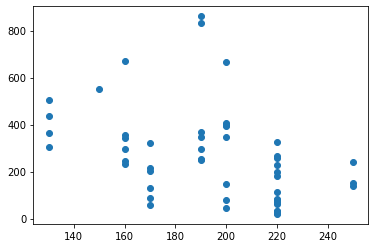

In [7]:
plt.scatter(t1['Retail Price'], t1['Avg Price Premium'])

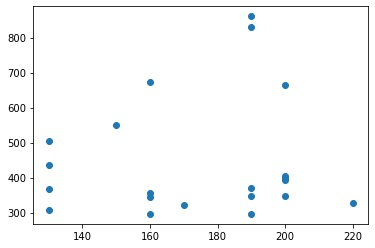

In [8]:
plt.scatter(t1.loc[:20, 'Retail Price'], t1.loc[:20, 'Avg Price Premium'])

In [8]:
t1.loc[:19, :].sort_values(['Avg Price Premium'], ascending=True).to_csv('price_premium.csv', index=False)

In [9]:
t1.loc[:19, :].to_csv('price_premium.csv', index=False)

### download images

In [34]:
for sneaker in t1.loc[:19, 'Sneaker Name']:
    for i in range(1, 37):
        counter = str(i).zfill(2)
        img = requests.get('https://stockx-360.imgix.net/' + sneaker + '/Images/' + sneaker + '/Lv2/img' + counter + '.jpg').content
        path = 'C:\\Users\\Jennifer\\Desktop\\Projects\\StockX\\images'
        file = sneaker + '_' + counter + '.jpg'

        with open(os.path.join(path, file), 'wb') as handler:
            handler.write(img)